# Notebook 03 – Exploratory Data Analysis

## Objective
Explore the cleaned dataset to understand feature distributions, identify relationships between variables, and uncover insights that can support future analysis and modeling.

---

### Checklist

- [x] Import libraries
- [x] Load the cleaned dataset
- [x] Create a working copy
- [x] Create derived features
- [x] Explore the dataset overview
- [x] Analyze numerical features
- [x] Analyze categorical features
- [x] Explore time-based patterns
- [x] Explore relationships between variables
- [x] Summarize key insights

## 1. Import Libraries

In [82]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

In [83]:
# Visualization settings

sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (8, 5)

## 2. Load the Cleaned Dataset

In [84]:
# Load the cleaned dataset
df_cleaned = pd.read_csv("../data/cleaned/online_retail_clean.csv")

# Display the first few rows
df_cleaned.head()

,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country
0,489434,85048,15CM CHRISTMAS GLASS BALL 20 LIGHTS,12,2009-12-01 07:45:00,6.95,13085.0,United Kingdom
1,489434,79323P,PINK CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom
2,489434,79323W,WHITE CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom
3,489434,22041,"RECORD FRAME 7"" SINGLE SIZE",48,2009-12-01 07:45:00,2.10,13085.0,United Kingdom
4,489434,21232,STRAWBERRY CERAMIC TRINKET BOX,24,2009-12-01 07:45:00,1.25,13085.0,United Kingdom


## 3. Create a Working Copy

In [85]:
# Create a working copy for analysis
df_analysis = df_cleaned.copy()

## 4. Create Derived Features

In [86]:
# Create total sales for each transaction
df_analysis["Sales"] = df_analysis["Quantity"] * df_analysis["Price"]

## 5. Explore the Dataset Overview

### 5.1 Dataset Structure

In [88]:
# Display dataset information
df_analysis.info()

<class 'pandas.DataFrame'>
RangeIndex: 505189 entries, 0 to 505188
Data columns (total 9 columns):
 #   Column       Non-Null Count   Dtype  
---  ------       --------------   -----  
 0   Invoice      505189 non-null  int64  
 1   StockCode    505189 non-null  str    
 2   Description  505189 non-null  str    
 3   Quantity     505189 non-null  int64  
 4   InvoiceDate  505189 non-null  str    
 5   Price        505189 non-null  float64
 6   Customer ID  400947 non-null  float64
 7   Country      505189 non-null  str    
 8   Sales        505189 non-null  float64
dtypes: float64(3), int64(2), str(4)
memory usage: 34.7 MB


### 5.2 Summary Statistics

In [89]:
# Display summary statistics for key numerical features
df_analysis[["Quantity", "Price", "Sales"]].describe()

,Quantity,Price,Sales
count,505189.000000,505189.000000,505189.000000
mean,11.564977,4.270077,20.332514
std,88.753508,64.062295,91.470190
min,1.000000,0.000000,0.000000
25%,1.000000,1.250000,4.200000
50%,3.000000,2.100000,10.200000
75%,12.000000,4.210000,17.700000
max,19152.000000,25111.090000,25111.090000


## 6. Analyze Numerical Features

### 6.1 Sales

#### Inspect

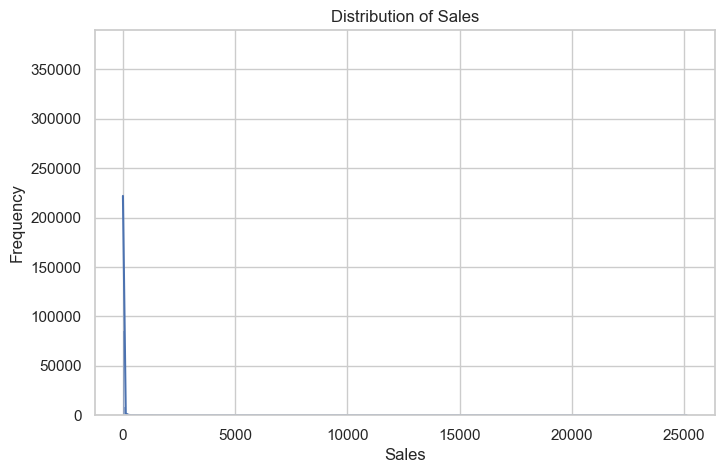

In [90]:
# Visualize the distribution of Sales using a histogram and KDE
plt.figure(figsize=(8, 5))

sns.histplot(
    data=df_analysis,
    x="Sales",
    kde=True
)

plt.title("Distribution of Sales")
plt.xlabel("Sales")
plt.ylabel("Frequency")

plt.show()

In [91]:
# Calculate the skewness of the Sales distribution
df_analysis["Sales"].skew()

np.float64(90.87672305851238)

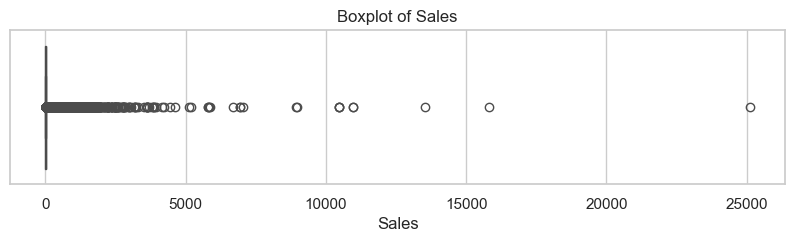

In [92]:
# Visualize potential outliers in the Sales distribution
plt.figure(figsize=(10, 2))

sns.boxplot(
    data=df_analysis,
    x="Sales"
)

plt.title("Boxplot of Sales")
plt.xlabel("Sales")

plt.show()

#### Interpretation

- The Sales distribution is highly right-skewed.
- Most transactions have relatively low sales values.
- A small number of high-value transactions create a long right tail and appear as potential outliers.

#### Decision

No outliers will be removed at this stage because they may represent genuine business transactions. If needed, additional visualizations without extreme values will be created later to better examine the main distribution.

### 6.2 Quantity

#### Inspect

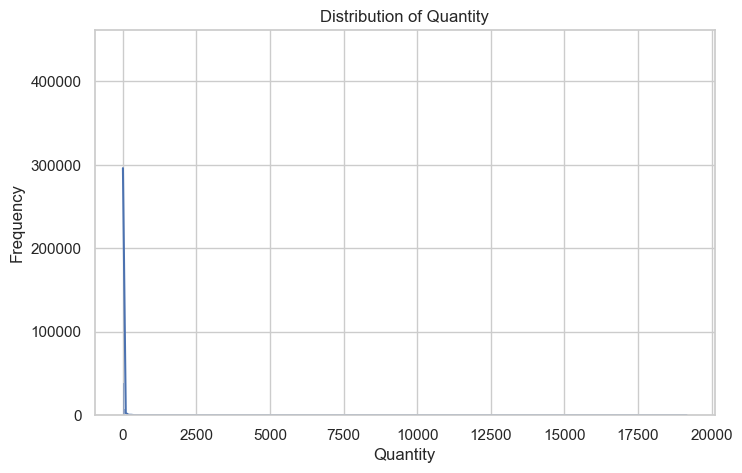

In [93]:
# Visualize the distribution of Quantity using a histogram and KDE
plt.figure(figsize=(8, 5))

sns.histplot(
    data=df_analysis,
    x="Quantity",
    kde=True
)

plt.title("Distribution of Quantity")
plt.xlabel("Quantity")
plt.ylabel("Frequency")

plt.show()

In [94]:
# Calculate the skewness of the Quantity distribution
df_analysis["Quantity"].skew()

np.float64(87.05726481510862)

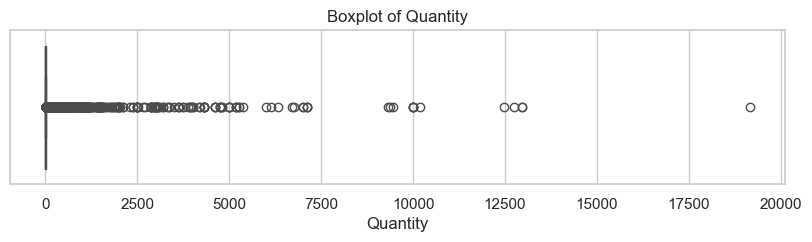

In [95]:
# Visualize potential outliers in the Quantity distribution
plt.figure(figsize=(10, 2))

sns.boxplot(
    data=df_analysis,
    x="Quantity"
)

plt.title("Boxplot of Quantity")
plt.xlabel("Quantity")

plt.show()

#### Interpretation

- The Quantity distribution is highly right-skewed.
- Most transactions involve relatively small purchase quantities.
- A small number of transactions contain exceptionally large quantities, resulting in a long right tail and numerous potential outliers.

#### Decision

No outliers will be removed at this stage because they may represent legitimate business transactions. If needed, additional visualizations without extreme values will be created later to better examine the main distribution.

### 6.3 Price

#### Inspect

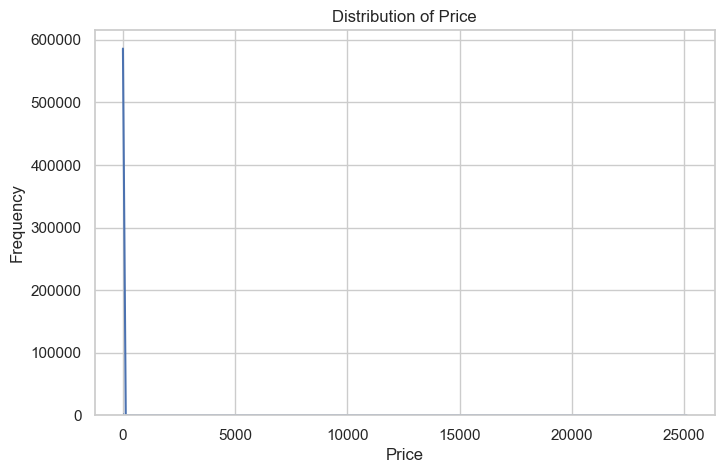

In [96]:
# Visualize the distribution of Price using a histogram and KDE
plt.figure(figsize=(8, 5))

sns.histplot(
    data=df_analysis,
    x="Price",
    kde=True
)

plt.title("Distribution of Price")
plt.xlabel("Price")
plt.ylabel("Frequency")

plt.show()

In [97]:
# Calculate the skewness of the Price distribution
df_analysis["Price"].skew()

np.float64(209.08073681880208)

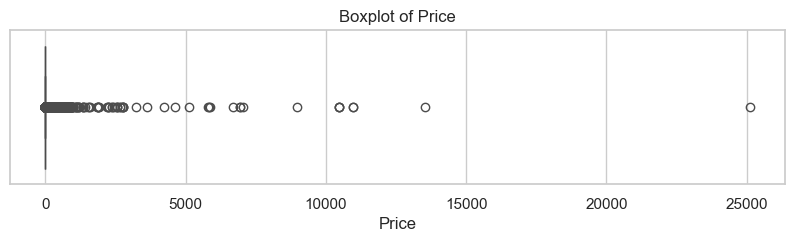

In [98]:
# Visualize potential outliers in the Price distribution
plt.figure(figsize=(10, 2))

sns.boxplot(
    data=df_analysis,
    x="Price"
)

plt.title("Boxplot of Price")
plt.xlabel("Price")

plt.show()

#### Interpretation

- The Price distribution is highly right-skewed.
- Most products have relatively low prices.
- A small number of products with exceptionally high prices create a long right tail and numerous potential outliers.

#### Decision

No outliers will be removed at this stage because they may represent legitimate product prices. If needed, additional visualizations without extreme values will be created later to better examine the main distribution.

## 7. Analyze Categorical Features

### 7.1 Country

#### Inspect

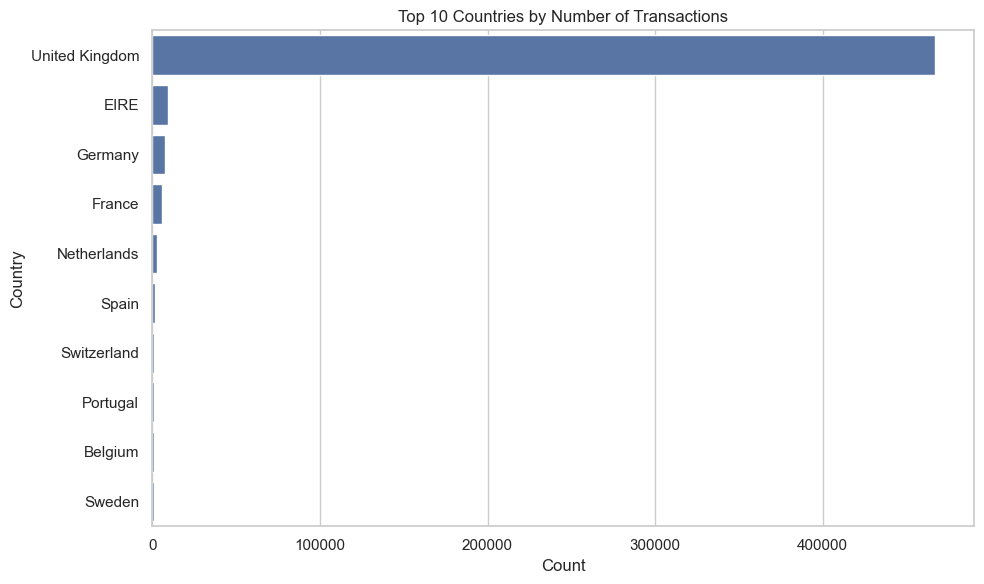

In [99]:
top_countries = df_analysis["Country"].value_counts().head(10)

plt.figure(figsize=(10, 6))

sns.barplot(
    x=top_countries.values,
    y=top_countries.index
)

plt.title("Top 10 Countries by Number of Transactions")
plt.xlabel("Count")
plt.ylabel("Country")

plt.tight_layout()
plt.show()

#### Interpretation

- A small number of countries account for most transactions.
- The United Kingdom is likely the dominant market.
- The remaining countries have significantly lower transaction counts.

#### Decision

No action is required at this stage. This distribution will be useful for later business-level analysis.

### 7.2 Products

#### Inspect

In [100]:
# Top 10 products by number of transactions (using StockCode)
top_products = df_analysis["StockCode"].value_counts().head(10)

In [101]:
# Map StockCode to most frequent Description
product_names = (
    df_analysis.groupby("StockCode")["Description"]
    .agg(lambda x: x.mode()[0])
)

In [102]:
top_products_df = top_products.reset_index()
top_products_df.columns = ["StockCode", "Count"]

top_products_df["Description"] = top_products_df["StockCode"].map(product_names)

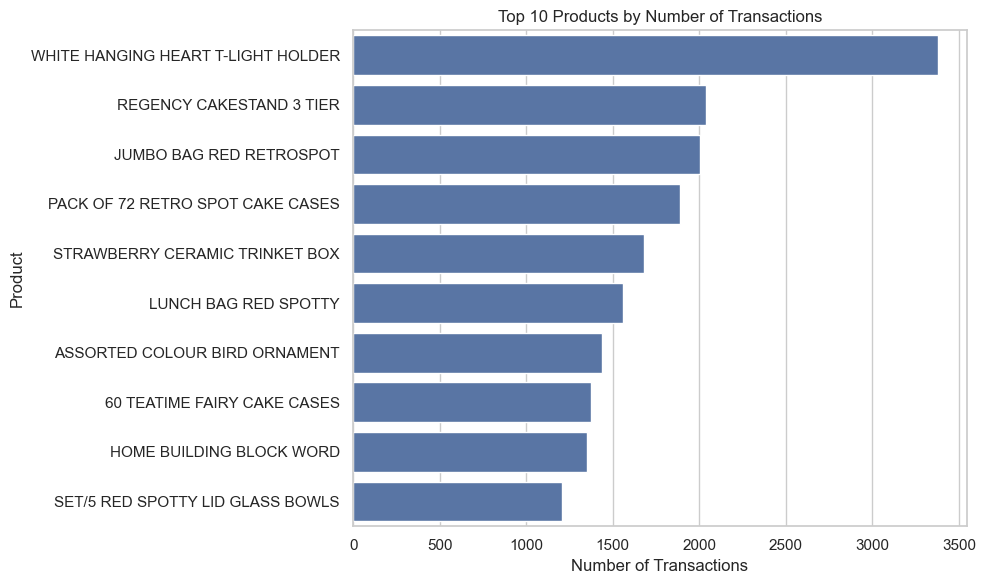

In [103]:
plt.figure(figsize=(10, 6))

sns.barplot(
    data=top_products_df,
    x="Count",
    y="Description"
)

plt.title("Top 10 Products by Number of Transactions")
plt.xlabel("Number of Transactions")
plt.ylabel("Product")

plt.tight_layout()
plt.show()

#### Interpretation

- A small number of products account for most transactions.
- These products can be considered the most frequently purchased items.
- However, transaction frequency does not necessarily reflect revenue contribution, as high-priced but less frequently purchased products are not captured here.

#### Decision

No action is required at this stage. This analysis provides a view of product popularity, which will later be complemented with revenue-based analysis.

## 8. Explore Time-Based Patterns

### 8.1 Transactions Over Time

#### Inspect

In [104]:
# Ensure InvoiceDate is datetime (just in case safety check)
df_analysis["InvoiceDate"] = pd.to_datetime(df_analysis["InvoiceDate"])

# Create daily transaction counts
daily_transactions = df_analysis.groupby(
    df_analysis["InvoiceDate"].dt.date
).size()

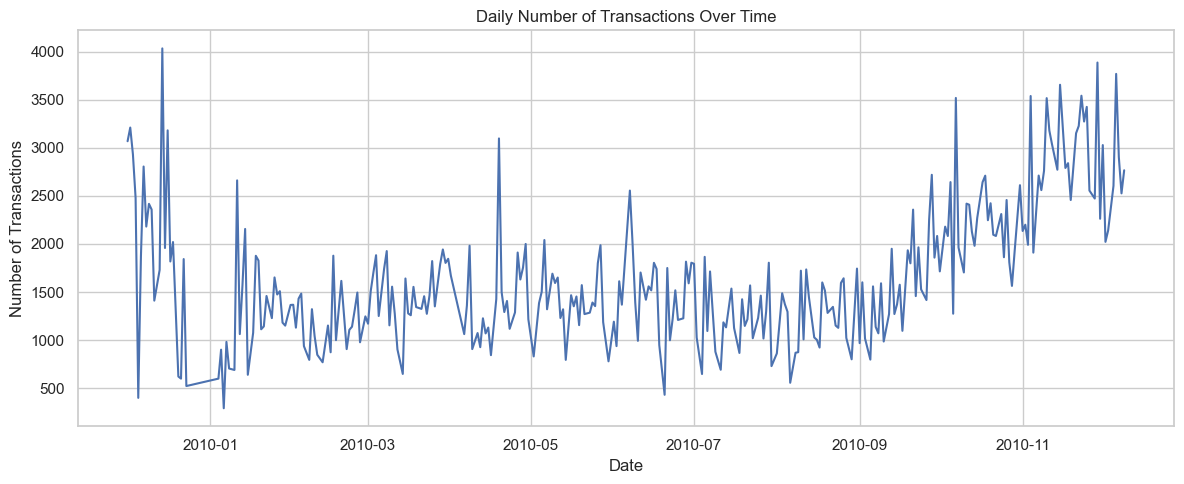

In [105]:
plt.figure(figsize=(12, 5))

daily_transactions.plot()

plt.title("Daily Number of Transactions Over Time")
plt.xlabel("Date")
plt.ylabel("Number of Transactions")

plt.tight_layout()
plt.show()

#### Interpretation

- The number of transactions fluctuates significantly over time.
- There is no smooth or stable trend in daily activity.
- The pattern suggests irregular purchasing behavior, likely influenced by external factors such as holidays, bulk orders, or operational cycles.

#### Decision

No action is required at this stage. The observed fluctuations are expected in transactional retail data and will be further analyzed in later time-based or business-level breakdowns.

### 8.2 Monthly Trend

In [106]:
# Extract month from InvoiceDate
df_analysis["YearMonth"] = df_analysis["InvoiceDate"].dt.to_period("M")

In [107]:
monthly_transactions = df_analysis.groupby("YearMonth").size()

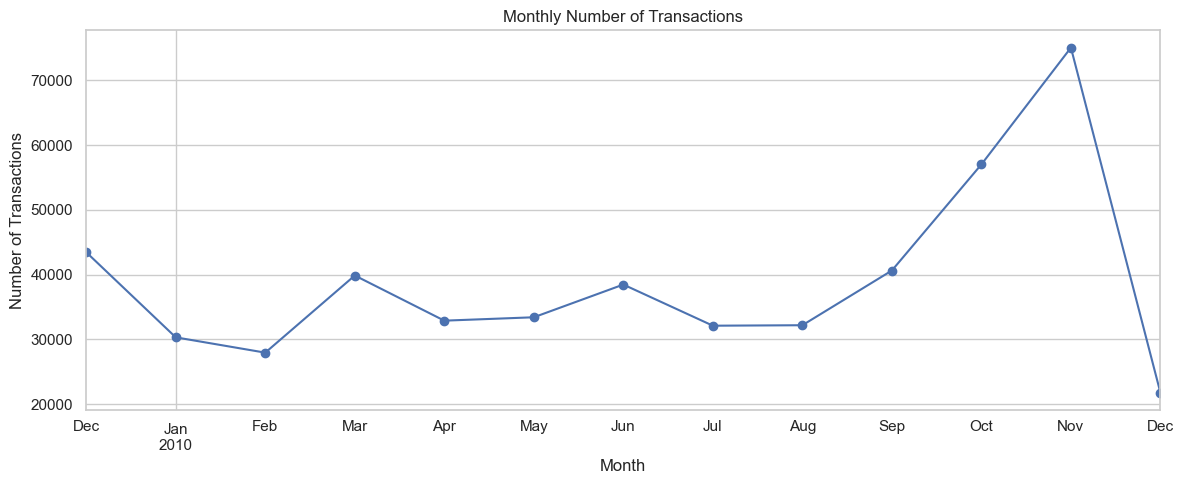

In [108]:
plt.figure(figsize=(12, 5))

monthly_transactions.plot(marker="o")

plt.title("Monthly Number of Transactions")
plt.xlabel("Month")
plt.ylabel("Number of Transactions")

plt.tight_layout()
plt.show()

#### Interpretation

- Monthly transactions show less noise compared to daily data.
- The overall pattern is more stable and easier to interpret at this aggregation level.
- Fluctuations still exist, suggesting that demand is not perfectly uniform across months.

#### Decision

No action is required at this stage. Monthly aggregation provides a clearer view of overall trends and will be useful for future business-level analysis.

## 9. Relationship Analysis

### 9.1 Country vs Sales

#### Inspect

In [109]:
# Total sales by country
country_sales = df_analysis.groupby("Country")["Sales"].sum().sort_values(ascending=False).head(10)

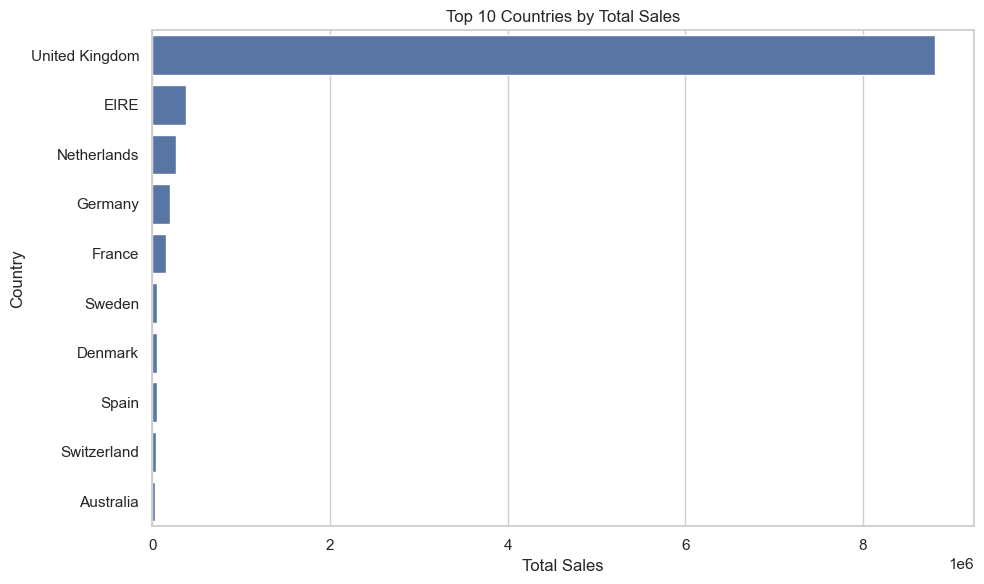

In [110]:
plt.figure(figsize=(10, 6))

sns.barplot(
    x=country_sales.values,
    y=country_sales.index
)

plt.title("Top 10 Countries by Total Sales")
plt.xlabel("Total Sales")
plt.ylabel("Country")

plt.tight_layout()
plt.show()

#### Interpretation

- There is a noticeable difference between transaction frequency and total sales by country.
- Some countries may have a high number of transactions but lower total sales, while others may generate higher revenue with fewer but higher-value purchases.
- This indicates that transaction volume alone is not a sufficient indicator of market importance; revenue provides a more accurate business perspective.

#### Decision

Both transaction count and total sales by country are important metrics and should be analyzed together in future business evaluations to obtain a more complete understanding of market performance.

### 9.2 Country vs Average Order Value

In [111]:
# Total sales and number of transactions per country
country_stats = df_analysis.groupby("Country").agg(
    total_sales=("Sales", "sum"),
    total_orders=("Invoice", "nunique")
)

# Average Order Value
country_stats["AOV"] = country_stats["total_sales"] / country_stats["total_orders"]

# Top 10 countries by AOV
top_aov = country_stats.sort_values("AOV", ascending=False).head(10)

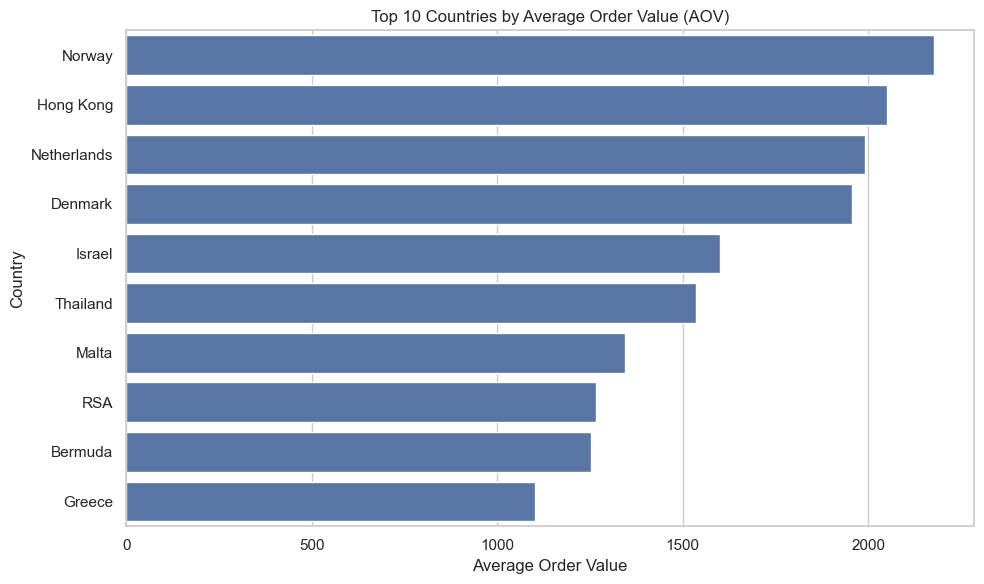

In [112]:
plt.figure(figsize=(10, 6))

sns.barplot(
    x=top_aov["AOV"].values,
    y=top_aov.index
)

plt.title("Top 10 Countries by Average Order Value (AOV)")
plt.xlabel("Average Order Value")
plt.ylabel("Country")

plt.tight_layout()
plt.show()

#### Interpretation

- Countries with the highest average order value are not necessarily the same countries with the highest number of transactions or total sales.
- This suggests differences in purchasing behavior across markets; some countries tend to place fewer but higher-value orders, which may indicate bulk purchasing or premium/wholesale behavior.
- The absence of the United Kingdom in the top AOV list, despite its dominance in transaction volume and total sales, indicates that its market is driven more by frequency of purchases rather than high-value orders.

#### Decision

Average Order Value should be analyzed alongside total sales and transaction count to properly understand market structure. No data changes are required at this stage.

### 9.3 Top Customers by Total Sales

#### Inspect

In [113]:
# Total sales per customer
top_customers = (
    df_analysis.groupby("Customer ID")["Sales"]
    .sum()
    .sort_values(ascending=False)
    .head(10)
    .reset_index()
)

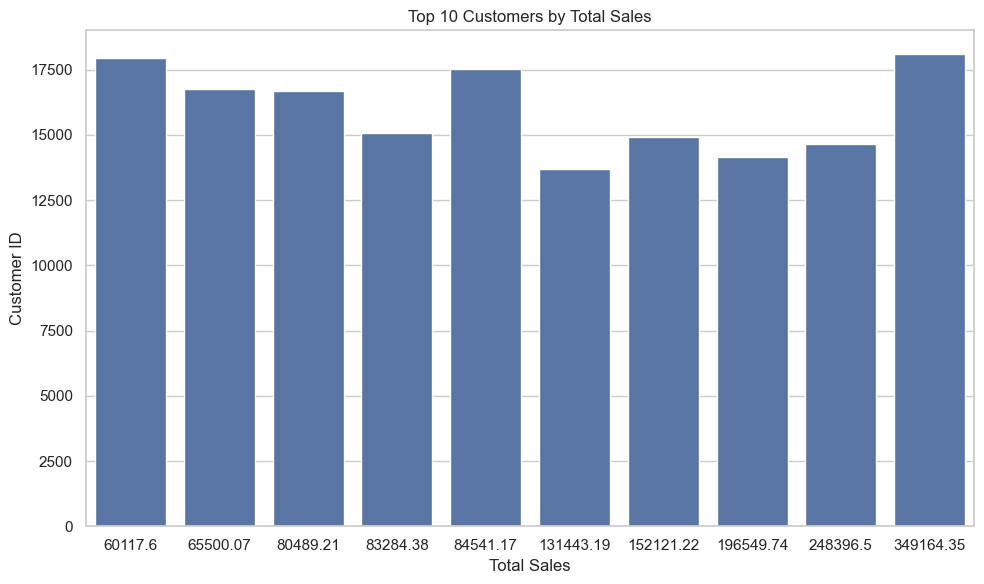

In [114]:
plt.figure(figsize=(10, 6))

sns.barplot(
    data=top_customers,
    x="Sales",
    y="Customer ID"
)

plt.title("Top 10 Customers by Total Sales")
plt.xlabel("Total Sales")
plt.ylabel("Customer ID")

plt.tight_layout()
plt.show()

#### Interpretation

- The total sales are relatively evenly distributed among the top customers.
- There is no strong evidence of a few dominant “VIP customers” driving most of the revenue.
- This suggests that the revenue base is more diversified across customers rather than being dependent on a small group.

#### Decision

No specific customer segmentation is required at this stage. However, customer-level analysis can be extended later if business questions require deeper segmentation (e.g., loyalty or retention analysis).

## 10. Summary of EDA

### 10.1 Key Findings

- The dataset shows a highly concentrated market in terms of geography, with a small number of countries accounting for the majority of transactions and revenue.
  
- Product analysis indicates that a limited set of products dominate transaction frequency, while overall product demand is relatively distributed.

- There is a clear distinction between transaction volume and revenue contribution across countries, highlighting that frequency of purchase does not always align with financial impact.

- Monthly trends show fluctuating activity without a strong linear growth pattern, suggesting seasonality or irregular purchasing behavior.

- Customer-level analysis reveals no significant dominance of a few customers, indicating a relatively diversified customer base.

### 10.2 Business Insights

- The business is driven more by transaction volume than by high-value individual orders in its dominant market.
  
- There is potential opportunity in identifying high-value purchasing behaviors in non-dominant countries.

- Product strategy may benefit from separating “high-frequency products” from “high-revenue products”.

- Stable customer distribution reduces dependency risk but may indicate lack of strong loyalty segmentation.

### 10.3 Limitations

- No deep seasonal decomposition was performed (e.g., weekly or yearly seasonality).
  
- Profitability analysis is limited to Sales without cost or margin information.
  
- Product descriptions contain inconsistencies, which may affect product-level insights.

### 10.4 Next Steps

- Perform time series decomposition for deeper seasonality analysis.
- Introduce profitability metrics if cost data becomes available.
- Segment customers for behavioral clustering (RFM analysis potential).
- Compare high-frequency vs high-value products for strategic insights.